# Backbone Model - Huấn luyện mô hình sử dụng backbone EfficientNet-B0

---

Mục tiêu là sử dụng mô hình `EfficientNet-B0` để huấn luyện mô hình dự đoán quét mặt gian lận

In [1]:
import os
import sys
import numpy as np
from math import ceil
from pathlib import Path

import tensorflow as tf
from keras.optimizers import AdamW
from keras.optimizers.schedules import CosineDecay
from keras.losses import BinaryFocalCrossentropy
from keras.utils import set_random_seed
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report

sys.path.append(os.path.abspath('..'))
from models.BackboneModel import backbone_model
from src.data import build_balanced_train_ds, build_eval_ds, clear_cache
from src.evaluate import MetricsCallback, plot_training_history, evaluate_model, calculate_metrics

I0000 00:00:1791597600.101620 1003842 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791597600.139249 1003842 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791597601.578035 1003842 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
IMG_SIZE = 224
EPOCHS = 30
WARMUP_EPOCHS = 5
BATCH_SIZE = 32
SEED = 42
OUTPUT_DIR = '../outputs/backbone-model'
CACHE = '../cache/backbone-model'

set_random_seed(SEED)

import shutil
if os.path.exists(CACHE):
    shutil.rmtree(CACHE)
os.makedirs(CACHE, exist_ok=True)
clear_cache(CACHE)

## 1. Chuẩn bị dữ liệu

---

In [3]:
train_dir = '../datasets/LCC_FASD/train'
val_dir   = '../datasets/LCC_FASD/val'
test_dir  = '../datasets/LCC_FASD/test'

train_ds = build_balanced_train_ds(train_dir, IMG_SIZE, BATCH_SIZE, cache_dir=CACHE, seed=SEED)
val_ds   = build_eval_ds(val_dir,  IMG_SIZE, BATCH_SIZE, 'val',  cache_dir=CACHE)
test_ds  = build_eval_ds(test_dir, IMG_SIZE, BATCH_SIZE, 'test', cache_dir=CACHE)

x, y = next(iter(train_ds))
print(x.shape, float(tf.reduce_min(x)), float(tf.reduce_max(x)), int(tf.reduce_sum(y)))

Train: 1219 real | 7004 spoof | mỗi batch 16 real + 16 spoof


E0000 00:00:1791597603.336692 1003842 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


val: 2934 ảnh
test: 7531 ảnh


W0000 00:00:1791597605.325796 1004002 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


(32, 224, 224, 3) 0.0 1.0 16


W0000 00:00:1791597607.875972 1003842 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## 2. Khởi tạo mô hình

---

Mô hình được xây dựng trong [CustomeModel](../models/CustomeModel.py)

In [4]:
input_shape = (IMG_SIZE, IMG_SIZE, 3)

model = backbone_model(input_shape=input_shape, num_classes=1, freeze_backbone=True)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,410,532 (16.82 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [5]:
metrics_callback = MetricsCallback(val_dataset=val_ds, threshold_path=OUTPUT_DIR + '/best_threshold.txt')

callbacks = [
    metrics_callback,

    ModelCheckpoint(
        filepath=OUTPUT_DIR + '/best_model.keras', 
        monitor='val_acer', 
        save_best_only=True, 
        mode='min', 
        verbose=1
    )
]

num_train = sum(1 for p in Path(train_dir).rglob('*.png') if p.is_file())
steps_per_epoch = ceil(num_train / BATCH_SIZE)

lr_schedule_stage_1 = CosineDecay(
    initial_learning_rate=0.000363,
    decay_steps=EPOCHS * steps_per_epoch
)

# Giảm learning rate xuống 0.00001 nhằm bảo vệ backbone
lr_schedule_stage_2 = CosineDecay(
    initial_learning_rate=0.00001,
    decay_steps=(EPOCHS - WARMUP_EPOCHS) * steps_per_epoch
)

W0000 00:00:1791597611.222877 1003842 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## 3. Huấn luyện mô hình

---

### 3.1 Giai đoạn 1 - Warm-up

In [6]:
model.compile(
    optimizer=AdamW(learning_rate=lr_schedule_stage_1, weight_decay=2e-3),
    loss=BinaryFocalCrossentropy(gamma=2.0),
    metrics=['accuracy']
)

history_stage_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=callbacks,
    steps_per_epoch=steps_per_epoch,
    shuffle=False
)

Epoch 1/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.7940 - loss: 0.1131 - APCER: 18.74% - BPCER: 18.77% - EER: 18.75% - ACER: 18.75% (t*: 0.5695) ⭐ NEW BEST

Epoch 1: val_acer improved from None to 0.18754, saving model to ../outputs/backbone-model/best_model.keras

Epoch 1: finished saving model to ../outputs/backbone-model/best_model.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 183s 684ms/step - accuracy: 0.7940 - loss: 0.1131 - val_accuracy: 0.8718 - val_loss: 0.0751 - val_apcer: 0.1874 - val_bpcer: 0.1877 - val_eer: 0.1875 - val_acer: 0.1875
Epoch 2/5
 23/257 ━━━━━━━━━━━━━━━━━━━━ 1:46 457ms/step - accuracy: 0.8370 - loss: 0.0911

W0000 00:00:1791597804.481585 1004175 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.8873 - loss: 0.0708 - APCER: 14.79% - BPCER: 14.81% - EER: 14.80% - ACER: 14.80% (t*: 0.6176) ⭐ NEW BEST

Epoch 2: val_acer improved from 0.18754 to 0.14802, saving model to ../outputs/backbone-model/best_model.keras

Epoch 2: finished saving model to ../outputs/backbone-model/best_model.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.8873 - loss: 0.0708 - val_accuracy: 0.8971 - val_loss: 0.0671 - val_apcer: 0.1479 - val_bpcer: 0.1481 - val_eer: 0.1480 - val_acer: 0.1480
Epoch 3/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 788ms/step - accuracy: 0.8875 - loss: 0.0710 - APCER: 13.13% - BPCER: 13.09% - EER: 13.11% - ACER: 13.11% (t*: 0.4931) ⭐ NEW BEST

Epoch 3: val_acer improved from 0.14802 to 0.13107, saving model to ../outputs/backbone-model/best_model.keras

Epoch 3: finished saving model to ../outputs/backbone-model/best_model.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 336s 1s/step - accuracy: 0.8875 - loss: 0.0710 - val_accuracy:

### 3.2 Giai đoạn 2 - Mở khóa toàn bộ mô hình

In [7]:
backbone = model.get_layer('efficientnetb0')
backbone.trainable = True
for layer in backbone.layers[:-30]:
    layer.trainable = False

for layer in backbone.layers[-30:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=AdamW(learning_rate=lr_schedule_stage_2, weight_decay=2e-3),
    loss=BinaryFocalCrossentropy(gamma=2.0),
    metrics=['accuracy']
)

history_stage_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=WARMUP_EPOCHS,
    epochs=EPOCHS,
    callbacks=callbacks,
    steps_per_epoch=steps_per_epoch,
    shuffle=False
)

Epoch 6/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 840ms/step - accuracy: 0.9365 - loss: 0.0442 - APCER: 12.85% - BPCER: 12.84% - EER: 12.85% - ACER: 12.85% (t*: 0.5894) 

Epoch 6: val_acer did not improve from 0.11373
257/257 ━━━━━━━━━━━━━━━━━━━━ 388s 1s/step - accuracy: 0.9365 - loss: 0.0442 - val_accuracy: 0.9138 - val_loss: 0.0654 - val_apcer: 0.1285 - val_bpcer: 0.1284 - val_eer: 0.1285 - val_acer: 0.1285
Epoch 7/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 852ms/step - accuracy: 0.9454 - loss: 0.0374 - APCER: 9.73% - BPCER: 9.63% - EER: 9.68% - ACER: 9.68% (t*: 0.5651) ⭐ NEW BEST

Epoch 7: val_acer improved from 0.11373 to 0.09678, saving model to ../outputs/backbone-model/best_model.keras

Epoch 7: finished saving model to ../outputs/backbone-model/best_model.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 345s 1s/step - accuracy: 0.9454 - loss: 0.0374 - val_accuracy: 0.9202 - val_loss: 0.0673 - val_apcer: 0.0973 - val_bpcer: 0.0963 - val_eer: 0.0968 - val_acer: 0.0968
Epoch 8/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 

In [8]:
combined_history = {}

for key in history_stage_1.history.keys():
    combined_history[key] = history_stage_1.history[key] + history_stage_2.history[key]

# 4. Đánh giá kết quả 

---

In [9]:
from keras.models import load_model

model = load_model(OUTPUT_DIR + '/best_model.keras')
threshold_best = float(open(OUTPUT_DIR + '/best_threshold.txt').read())
print(f"Ngưỡng tốt nhất: {threshold_best}")

y_prob = model.predict(test_ds)
y_pred = (y_prob >= threshold_best).astype(int).flatten()

y_true = np.concatenate([y.numpy() if hasattr(y, 'numpy') else y for x, y in test_ds], axis=0).flatten()

print(classification_report(y_true, y_pred))

Ngưỡng tốt nhất: 0.5725393891334534
236/236 ━━━━━━━━━━━━━━━━━━━━ 93s 386ms/step


W0000 00:00:1791606123.403326 1003842 cache_dataset_ops.cc:330] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


              precision    recall  f1-score   support

         0.0       0.26      0.90      0.41       314
         1.0       1.00      0.89      0.94      7217

    accuracy                           0.89      7531
   macro avg       0.63      0.89      0.67      7531
weighted avg       0.96      0.89      0.92      7531



Đã lưu biểu đồ lịch sử tại: ../outputs/backbone-model/training_history.png


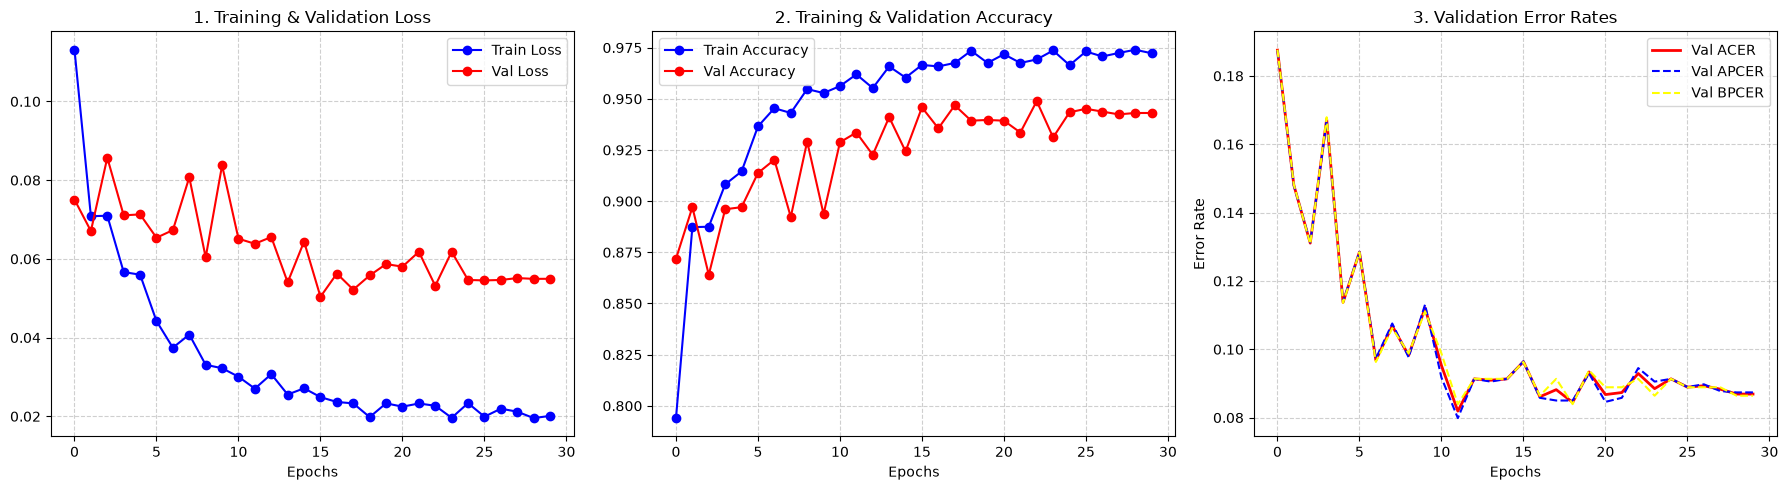

In [10]:
plot_training_history(combined_history, output=OUTPUT_DIR + '/training_history.png')

In [11]:
y_val_prob = model.predict(val_ds)
y_val_true = np.concatenate([y.numpy() if hasattr(y, 'numpy') else y for x, y in val_ds], axis=0).flatten()

92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 365ms/step


Đã lưu biểu đồ tại: ../outputs/backbone-model/evaluation_report.png


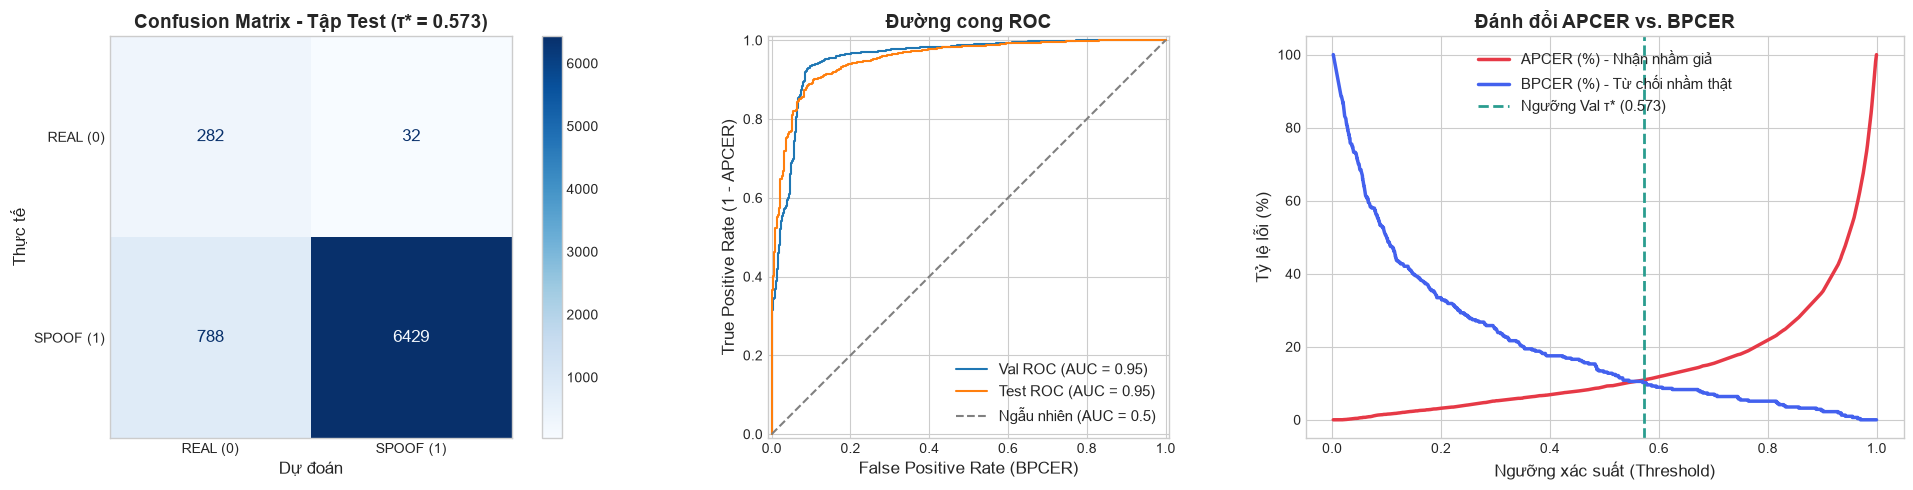

In [12]:
# Đánh giá và vẽ biểu đồ
y_test = (y_true, y_prob)
y_val = (y_val_true, y_val_prob)

evaluate_model(y_test, y_val, threshold_best, output=OUTPUT_DIR + '/evaluation_report.png')

In [13]:
metrics = calculate_metrics(y_true, y_prob, threshold_best)

print("Metrics on test set:")
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

Metrics on test set:
EER (%): 10.5096
APCER (%): 10.9187
BPCER (%): 10.1911
ACER (%): 10.5549
AUC (%): 95.3222
ACC (%): 89.1117
